In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pybinding as pb
import random
import itertools

from pybinding.repository import graphene
from math import sqrt, pi

In [3]:
cellSize = 11

a = 0.24595  # [nm] unit cell length
a_cc = 0.142  # [nm] carbon-carbon distance
t = -2.8  # [eV] nearest neighbour hopping

a1 = np.array([a, 0])
a2 = np.array([a / 2, a / 2 * sqrt(3)])

kp = np.array([0, 2])

def monolayer_graphene():
    lat = pb.Lattice(a1, a2)
    lat.add_sublattices(('A', [0, -a_cc / 2]),
                        ('B', [0, a_cc / 2]))
    lat.add_hoppings(
        # inside the main cell
        ([0, 0], 'A', 'B', t),
        # between neighboring cells
        ([1, -1], 'A', 'B', t),
        ([0, -1], 'A', 'B', t)
    )
    return lat


model = pb.Model(
    monolayer_graphene(),
    pb.primitive(a1=cellSize, a2=cellSize),
    pb.translational_symmetry(a1=cellSize * graphene.a, a2=cellSize * graphene.a),
)

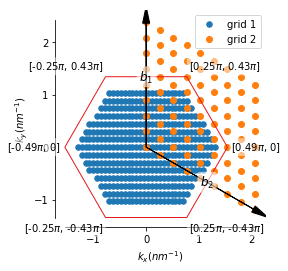

81


In [4]:
aSupper = cellSize * a

# grid 1
b = 2 * np.pi / aSupper  # Reciprocal lattice vector of the super lattice

nn = 4  # ncrease this value to increase the sampling of K-points in BZ
pp = 8 * nn

nnx = int(round(pp * 2 / np.sqrt(3)))
ddnx = (2 * b / np.sqrt(3)) / nnx

nny = int(pp)
ddny = b / nny

kx1 = np.linspace((-b / np.sqrt(3)) - ddnx / 2, (b / np.sqrt(3)) + ddnx / 2, nnx + 1)
ky1 = np.linspace(-b - ddny / 2, b + ddny / 2, nny + 1)

bb = b
kk1 = 0

temp1 = np.zeros((round((nnx * nny) * (3 / 8)), 2))
for ii in range(0, nnx):
    for jj in range(0, nny):
        kx = kx1[ii]
        ky = ky1[jj]
        if ((np.sqrt(3) * kx - b) <= ky and (ky <= (-np.sqrt(3) * kx + b)  # this condition make the hexagonal shape
                                             and (np.sqrt(3) * kx + b) >= ky) and (ky >= -np.sqrt(3) * kx - b)
                and (-b / 2 <= ky) and (ky <= b / 2)):
            kk1 = kk1 + 1
            temp1[kk1, 0] = kx
            temp1[kk1, 1] = ky

sample = temp1[0:kk1 + 1, :]  # for nn = 2: 21, nn = 3:

kx = sample[:, 0]
ky = sample[:, 1]


# grid 2
superlattice = pb.Lattice(a1=cellSize * a1, a2=cellSize * a2)
superlattice.plot_brillouin_zone()

Nx = Ny = 9
b1, b2 = superlattice.reciprocal_vectors()
nx, ny = np.arange(Nx), np.arange(Ny)
N = np.meshgrid(nx, ny)
k = np.outer(N[0].flatten(), b1) / Nx + np.outer(N[1].flatten(), b2) / Ny

plt.scatter(kx, ky, s=30, c='C0', label='grid 1')
plt.scatter(k[:, 0], k[:, 1], c='C1', label='grid 2')
plt.legend()
plt.show()

E = 10

data_grid1 = 0
data_grid2 = 0

print(len(k))


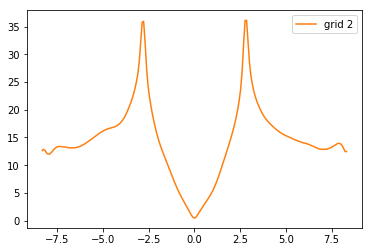

In [9]:
solver = pb.solver.lapack(model)

import time

# go over grid 2
for i, kki in enumerate(k):
    model.set_wave_vector(kki)
    kpm_dos = pb.kpm(model, silent=True).calc_dos(np.linspace(-E, E, 250), broadening=0.1,
                                     num_random=50)
    #time.sleep(0.01)
    #kpm_dos = solver.calc_dos(np.linspace(-E, E, 250), broadening=0.1)
    data_grid2 += kpm_dos.data
    #print(i, kki)
data_grid2 = data_grid2 / k.shape[0]

#plt.plot(np.linspace(-E, E, 250), data_grid1, label='grid 1', color='C0')
plt.plot(np.linspace(-E, E, 250), data_grid2, label='grid 2', color='C1')
plt.legend()
plt.show()